In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function 

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable 

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# acspsw03

In [4]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',

]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# load X features

In [5]:
psych = pd.read_csv(r'C:\Users\gregn\jupyter\ABCD_sipping_paper\psychological\X_features_psychological.csv')
abcd = pd.merge(psych, acspsw03, on='subjectkey', how='left')
X = abcd.drop(columns=['subjectkey', 'rel_family_id'])
X_values = X.values

print('number of features:', X.shape[1])
print('number of subjects:', X.shape[0])
list(X.columns)

number of features: 127
number of subjects: 10707


['nihtbx_picvocab_fc',
 'nihtbx_flanker_fc',
 'nihtbx_list_fc',
 'nihtbx_cardsort_fc',
 'nihtbx_pattern_fc',
 'nihtbx_picture_fc',
 'nihtbx_reading_fc',
 'nihtbx_fluidcomp_fc',
 'nihtbx_cryst_fc',
 'nihtbx_totalcomp_fc',
 'lmt_efficiency',
 'ravlt_immediate',
 'ravlt_learning',
 'ravlt_forgetting',
 'ravlt_percent_forgetting',
 'ravlt_proactive_interference',
 'ravlt_percent_total_learning',
 'upps6_y',
 'upps7_y',
 'upps11_y',
 'upps12_y',
 'upps15_y',
 'upps16_y',
 'upps17_y',
 'upps18_y',
 'upps19_y',
 'upps20_y',
 'upps21_y',
 'upps22_y',
 'upps23_y',
 'upps24_y',
 'upps27_y',
 'upps28_y',
 'upps35_y',
 'upps36_y',
 'upps37_y',
 'upps39_y',
 'bisbas1_y',
 'bisbas2_y',
 'bisbas3_y',
 'bisbas4_y',
 'bisbas6_y',
 'bisbas7_y',
 'bisbas8_y',
 'bisbas10_y',
 'bisbas9_y',
 'bisbas11_y',
 'bisbas12_y',
 'bisbas13_y',
 'bisbas14_y',
 'bisbas15_y',
 'bisbas16_y',
 'bisbas17_y',
 'bisbas18_y',
 'bisbas19_y',
 'bisbas20_y',
 'bisbas5r_y',
 'nback_acc_diff',
 'nback_rt_diff',
 'nback_acc_face_p

# repeated nested cross validation 


Run 1
8 grid search candidates

Runtime for run 1: 0:07:02.654300

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127526998519897

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787032    5.787032
1                      upps27_y    0.094567  5.521346   11.308378
2                     bisbas1_y    0.091110  5.319488   16.627867
3                      upps12_y    0.075561  4.411642   21.039509
4                      upps28_y    0.063981  3.735592   24.775101
5   upps_y_ss_sensation_seeking    0.055601  3.246302   28

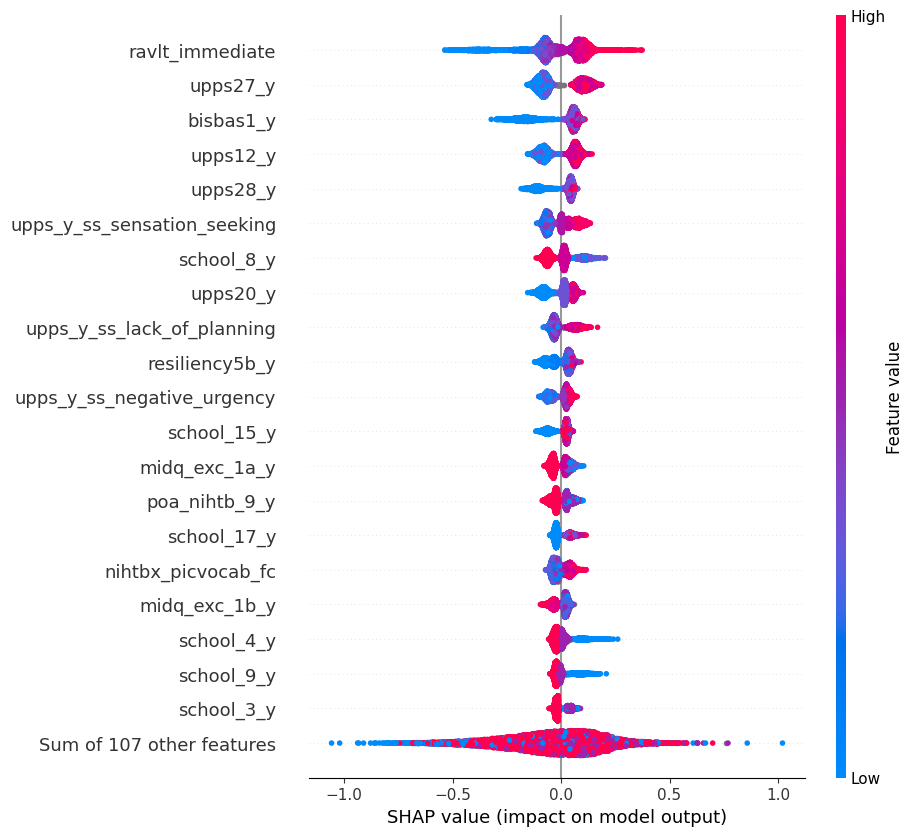


Run 2
8 grid search candidates

Runtime for run 2: 0:06:54.418778

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127515077590942

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099117  5.787030    5.787030
1                      upps27_y    0.094567  5.521341   11.308371
2                     bisbas1_y    0.091110  5.319498   16.627869
3                      upps12_y    0.075560  4.411635   21.039503
4                      upps28_y    0.063981  3.735597   24.775101
5   upps_y_ss_sensation_seeking    0.055601  3.246297   28

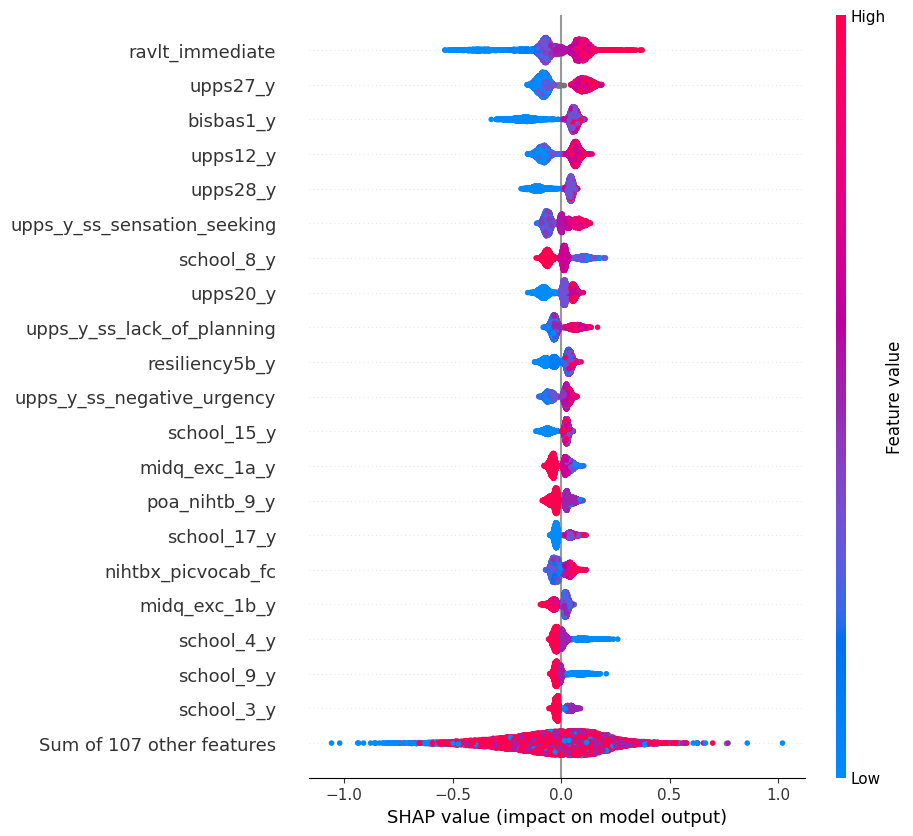


Run 3
8 grid search candidates

Runtime for run 3: 0:06:52.447440

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127529382705688

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787034    5.787034
1                      upps27_y    0.094567  5.521353   11.308387
2                     bisbas1_y    0.091110  5.319504   16.627892
3                      upps12_y    0.075561  4.411643   21.039534
4                      upps28_y    0.063982  3.735603   24.775137
5   upps_y_ss_sensation_seeking    0.055601  3.246303   28

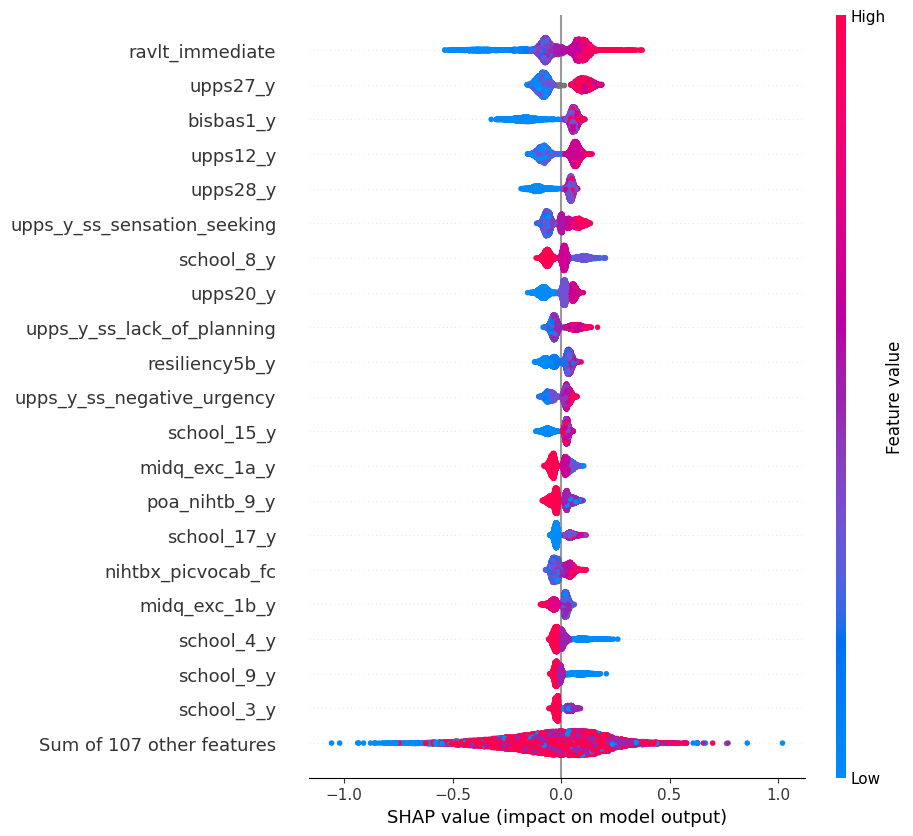


Run 4
8 grid search candidates

Runtime for run 4: 0:06:52.554104

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127524614334106

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787031    5.787031
1                      upps27_y    0.094567  5.521344   11.308374
2                     bisbas1_y    0.091110  5.319500   16.627874
3                      upps12_y    0.075560  4.411632   21.039505
4                      upps28_y    0.063982  3.735604   24.775108
5   upps_y_ss_sensation_seeking    0.055601  3.246307   28

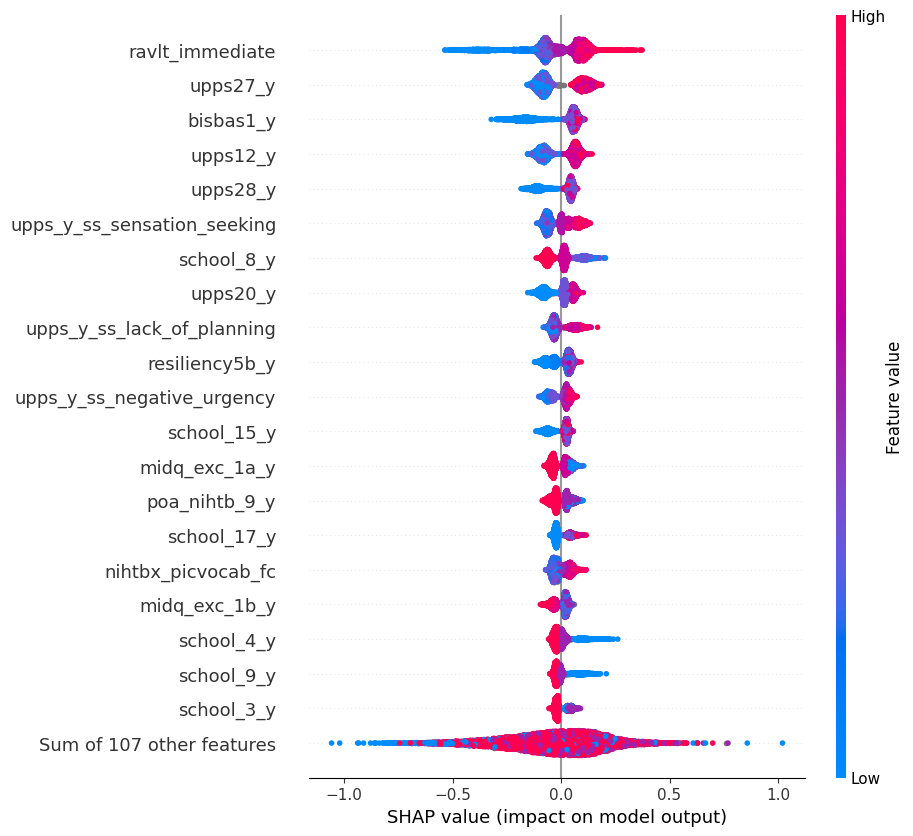


Run 5
8 grid search candidates

Runtime for run 5: 0:06:53.096759

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127526998519897

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787041    5.787041
1                      upps27_y    0.094567  5.521348   11.308388
2                     bisbas1_y    0.091110  5.319492   16.627880
3                      upps12_y    0.075560  4.411637   21.039516
4                      upps28_y    0.063982  3.735600   24.775116
5   upps_y_ss_sensation_seeking    0.055601  3.246301   28

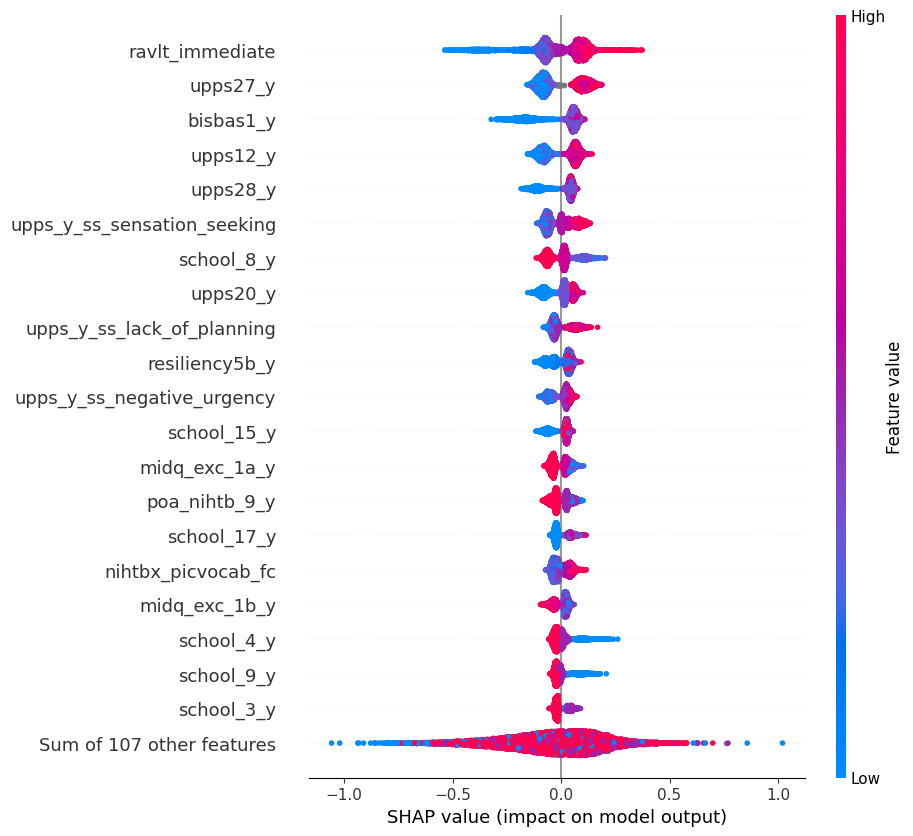


Run 6
8 grid search candidates

Runtime for run 6: 0:06:55.724788

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.712751865386963

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099117  5.787025    5.787025
1                      upps27_y    0.094567  5.521344   11.308369
2                     bisbas1_y    0.091110  5.319489   16.627857
3                      upps12_y    0.075560  4.411640   21.039497
4                      upps28_y    0.063982  3.735609   24.775106
5   upps_y_ss_sensation_seeking    0.055601  3.246297   28.

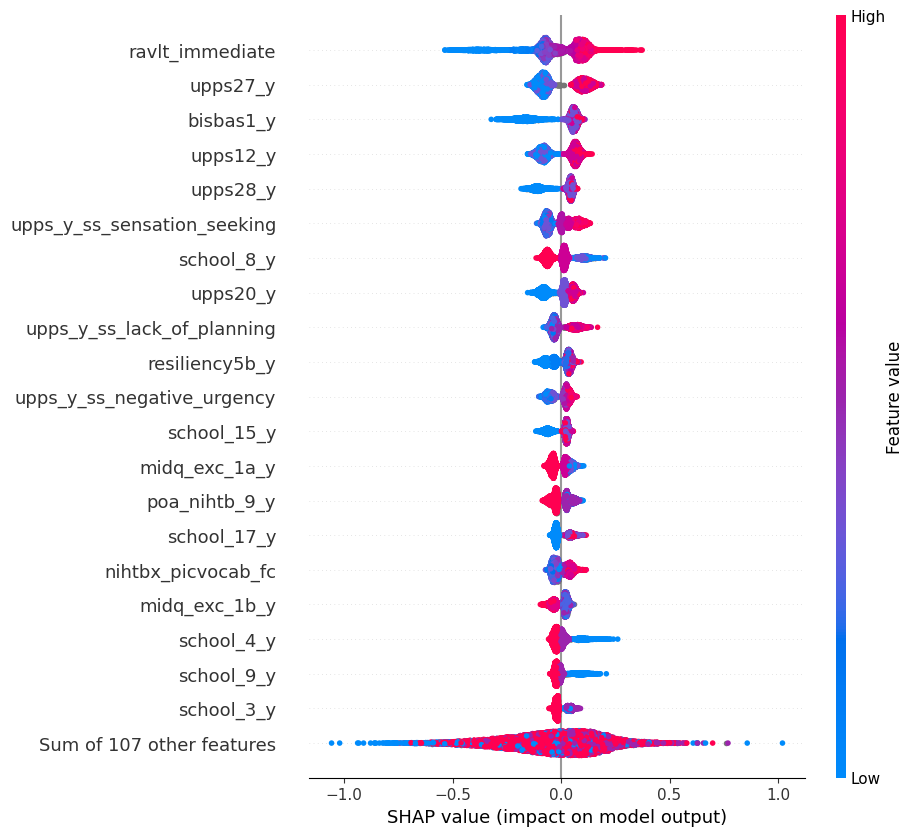


Run 7
8 grid search candidates

Runtime for run 7: 0:06:54.308037

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127526998519897

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787040    5.787040
1                      upps27_y    0.094567  5.521352   11.308392
2                     bisbas1_y    0.091110  5.319502   16.627893
3                      upps12_y    0.075560  4.411636   21.039530
4                      upps28_y    0.063982  3.735602   24.775131
5   upps_y_ss_sensation_seeking    0.055601  3.246302   28

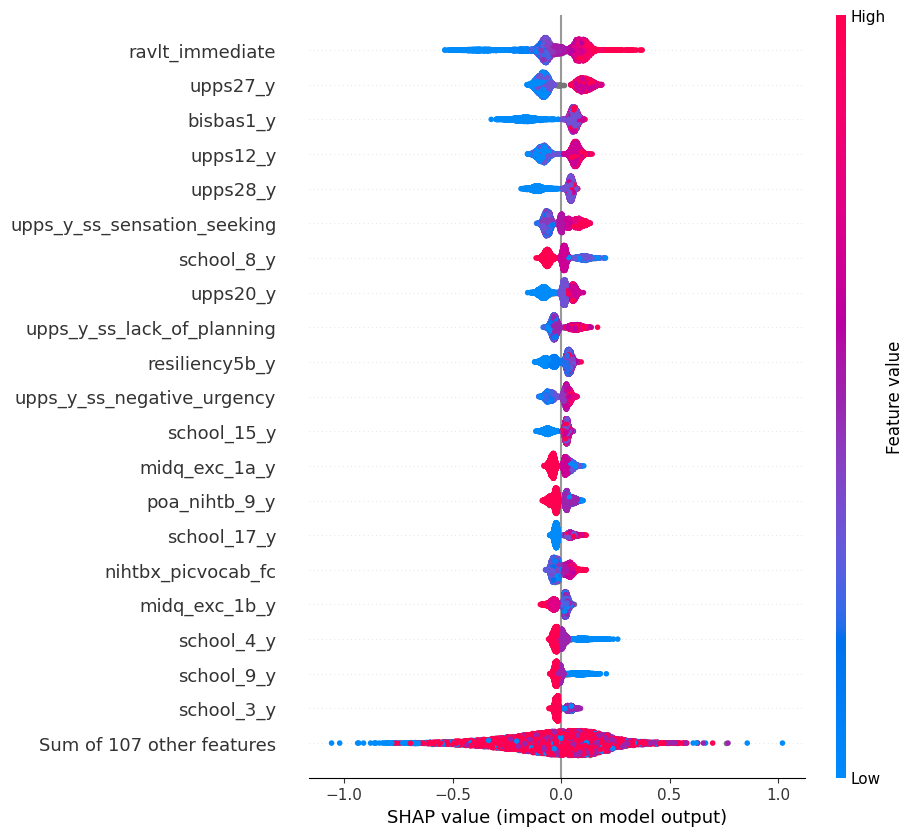


Run 8
8 grid search candidates

Runtime for run 8: 0:06:52.233999

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127524614334106

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787033    5.787033
1                      upps27_y    0.094567  5.521355   11.308388
2                     bisbas1_y    0.091110  5.319513   16.627901
3                      upps12_y    0.075560  4.411628   21.039528
4                      upps28_y    0.063982  3.735595   24.775124
5   upps_y_ss_sensation_seeking    0.055601  3.246303   28

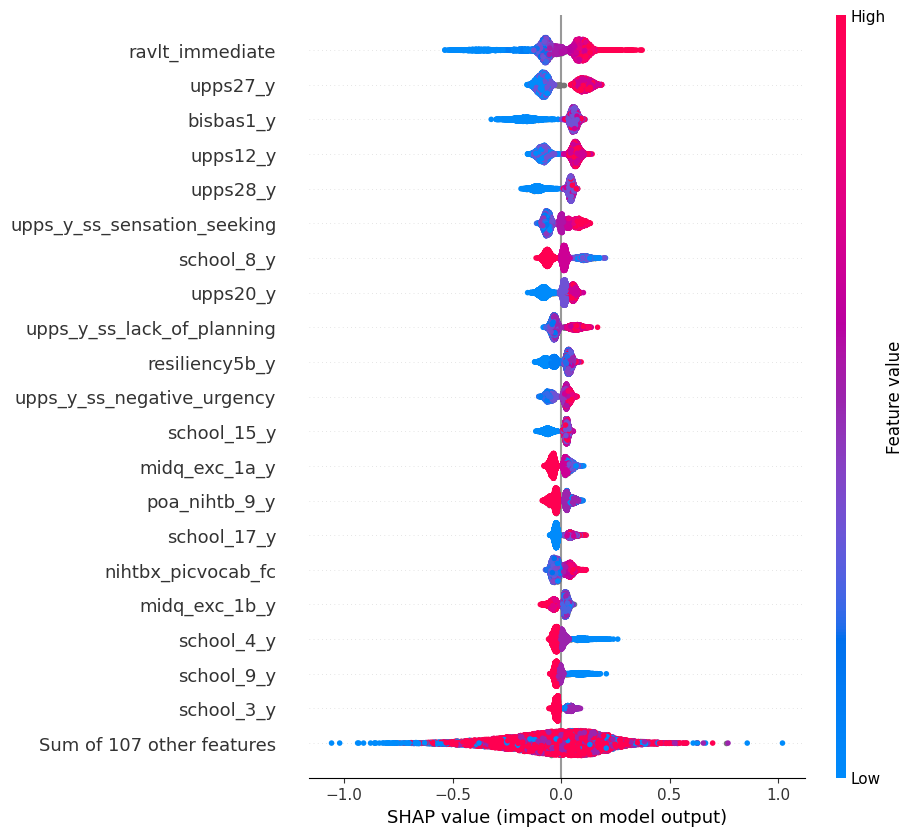


Run 9
8 grid search candidates

Runtime for run 9: 0:06:56.678601

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127525806427002

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099117  5.787017    5.787017
1                      upps27_y    0.094567  5.521342   11.308359
2                     bisbas1_y    0.091110  5.319511   16.627871
3                      upps12_y    0.075560  4.411631   21.039501
4                      upps28_y    0.063982  3.735602   24.775103
5   upps_y_ss_sensation_seeking    0.055601  3.246296   28

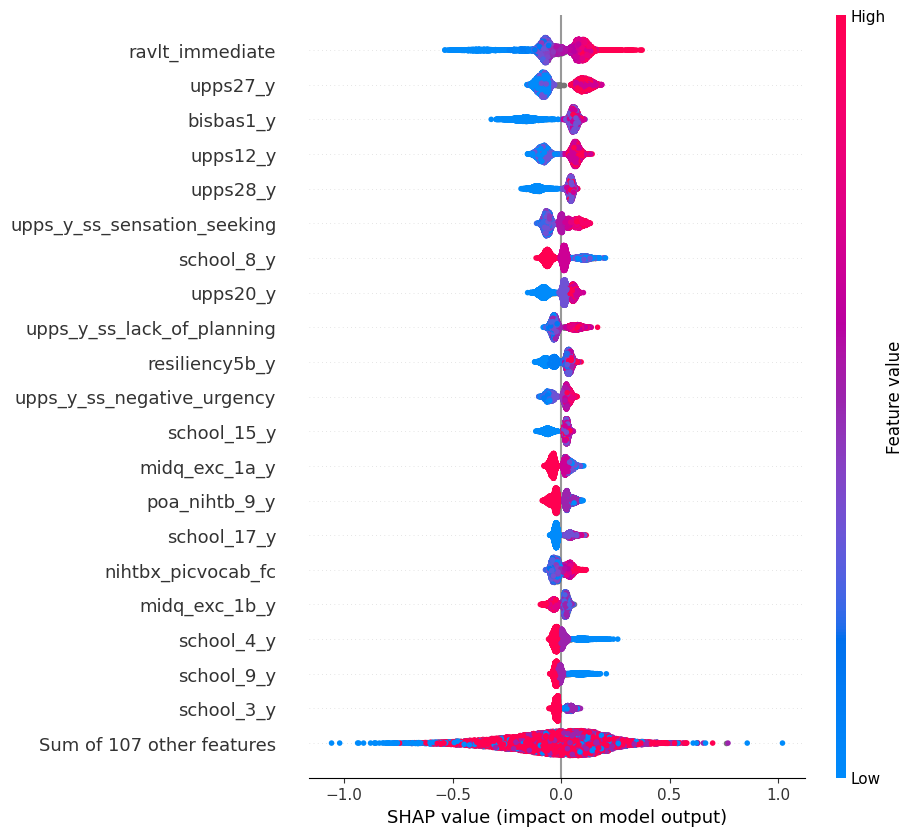


Run 10
8 grid search candidates

Runtime for run 10: 0:06:55.174265

Average ROC AUC score:   0.6535 [0.6563156  0.66337857 0.63494493 0.64279774 0.6702725 ]
Average accuracy score:  0.8601 [0.85994398 0.85994398 0.86034563 0.86034563 0.85987856]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'n_estimators': 1000}

Sum of SHAP values: 1.7127522230148315

Top 20 features by SHAP value:
                        feature  SHAP value   percent  cumulative
0               ravlt_immediate    0.099118  5.787033    5.787033
1                      upps27_y    0.094567  5.521342   11.308374
2                     bisbas1_y    0.091110  5.319509   16.627884
3                      upps12_y    0.075560  4.411634   21.039518
4                      upps28_y    0.063982  3.735609   24.775127
5   upps_y_ss_sensation_seeking    0.055601  3.246297   

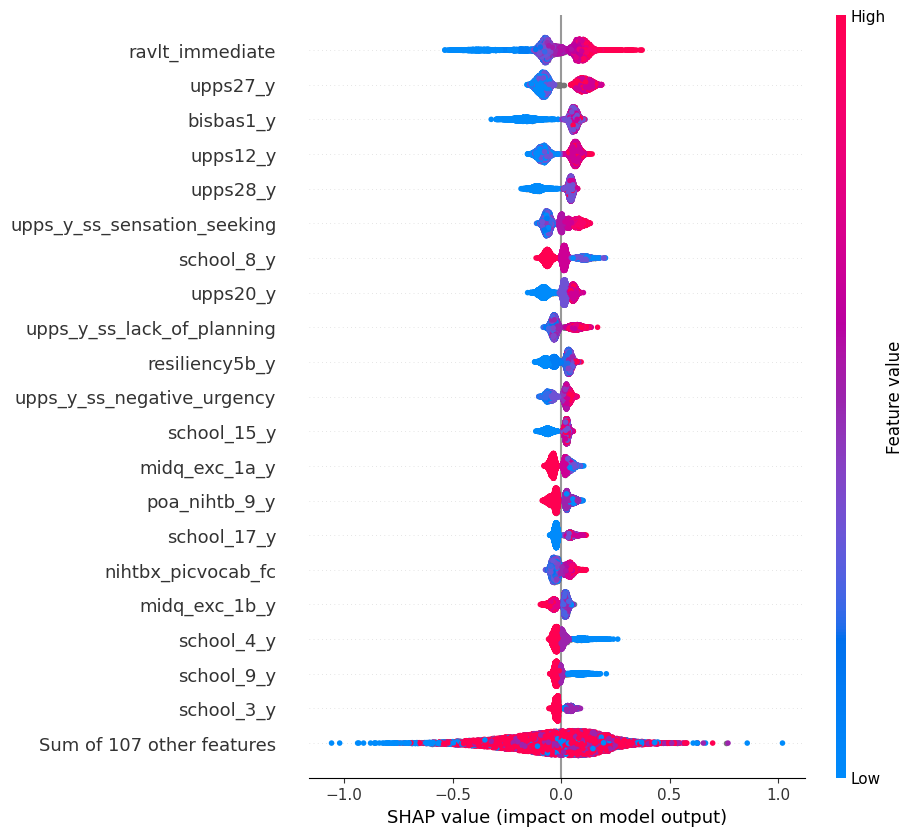


Total runtime for all runs: 2:06:56.005898


In [6]:
def run_nested_cv(num_runs=10):
    overall_start = time()
    
    # define the hyperparameter grid and scoring metrics
    params = {
        'learning_rate': [0.005, 0.01],
        'max_depth': [4, 8],
        'n_estimators': [500, 1000],

    }
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
       
    for run in range(1, num_runs+1):
        print(f"\n{'='*60}\nRun {run}\n{'='*60}")
        run_start = time()
        
        # shuffle the data before assigning family_groups
        perm = np.random.permutation(len(y))
        X_values_shuffled = X_values[perm]
        y_shuffled = y[perm]
        # shuffle the abcd dataframe so we can recompute family_groups from the family id column
        abcd_shuffled = abcd.iloc[perm].reset_index(drop=True)
        
        # recompute family groups from the shuffled 'rel_family_id' column
        d = defaultdict(lambda: len(d))
        family_groups_shuffled = np.array([d[x] for x in abcd_shuffled['rel_family_id']])
        
        # create a new model for each run 
        model = XGBClassifier(
            tree_method='gpu_hist',
            objective='binary:logistic',
            eval_metric='auc',
            colsample_bytree=0.4
        )
        
        # inner loop 
        inner_cv = GroupKFold(n_splits=5)
        inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)

        # outer loop
        outer_cv = GroupKFold(n_splits=5)
        outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)
        
        # setup GridSearchCV
        gs = GridSearchCV(
            estimator=model, 
            param_grid=params, 
            scoring='roc_auc', 
            cv=inner_cv,
            return_train_score=True,
            verbose=0  
        )
        
        # fit GridSearchCV 
        gs.fit(X_values, y)
        
        # run nested CV using cross_validate
        nested_scores = cross_validate(
            gs,
            X=X_values, 
            y=y, 
            scoring=scoring, 
            cv=outer_cv
        )
        
        # score arrays
        auc = nested_scores['test_roc_auc']
        acc = nested_scores['test_accuracy']
        precision = nested_scores['test_precision']
        recall = nested_scores['test_recall']
        f1 = nested_scores['test_f1']
        
        run_runtime = timedelta(seconds=time() - run_start)
        print(f"{len(ParameterGrid(params))} grid search candidates")
        print(f"\nRuntime for run {run}: {run_runtime}\n")
        print(f'Average ROC AUC score:   {auc.mean():.4f} {auc}')
        print(f'Average accuracy score:  {acc.mean():.4f} {acc}')
        print(f'Average precision score: {precision.mean():.4f} {precision}')
        print(f'Average recall score:    {recall.mean():.4f} {recall}')
        print(f'Average F1 score:        {f1.mean():.4f} {f1}')
        print('\nBest parameters:', gs.best_params_)
        
        # save the GridSearchCV object and nested scores 
        joblib.dump(gs, f'psychological_gridsearch_run{run}.pkl')
        joblib.dump(nested_scores, f'psychological_nested_scores_run{run}.pkl')
        
        # obtain model scores from outer folds
        y_scores = cross_val_predict(
            gs, 
            X_values_shuffled, 
            y_shuffled, 
            cv=outer_cv, 
            method='predict_proba', 
            
        )[:, 1]
        # save y_true and y_scores as a CSV
        df_scores = pd.DataFrame({'y_true': y_shuffled, 'y_scores': y_scores})
        df_scores.to_csv(f'psychological_y_true_y_scores_run{run}.csv', index=False)
        
        # SHAP analysis: create an explainer, compute SHAP values, and display a beeswarm plot
        explainer = shap.Explainer(gs.best_estimator_)
        # use the shuffled features
        X_shuffled = X.iloc[perm].reset_index(drop=True)
        shap_values = explainer(X_shuffled)
        
        # create SHAP ranking dataframe
        features = X_shuffled.columns 
        sv_mean = np.abs(shap_values.values).mean(0)
        sv_rank = pd.DataFrame(list(zip(features, sv_mean)), columns=['feature', 'SHAP value'])
        sv_rank = sv_rank.sort_values(by='SHAP value', ascending=False)
        sv_rank['percent'] = sv_rank['SHAP value'] / sv_rank['SHAP value'].sum() * 100
        sv_rank['cumulative'] = sv_rank['percent'].cumsum()
        sv_rank.reset_index(inplace=True, drop=True)
        sv_rank.to_csv(f'psychological_shap_ranking_run{run}.csv', index=False)
        
        print(f"\nSum of SHAP values: {sv_rank['SHAP value'].sum()}")
        print("\nTop 20 features by SHAP value:")
        print(sv_rank.head(20))
        
        # display SHAP beeswarm plot
        shap.plots.beeswarm(shap_values, max_display=21)

        
    overall_runtime = timedelta(seconds=time() - overall_start)
    print(f"\n{'='*60}\nTotal runtime for all runs: {overall_runtime}\n{'='*60}")


run_nested_cv(num_runs=10)